In [101]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import math

In [102]:
def create_random_cube():
    center = np.random.uniform(-5, 5, size=(3,))
    size = np.random.uniform(1, 3)
    base_vertices = np.array([
        [-1, -1, -1], [1, -1, -1], [1, 1, -1], [-1, 1, -1],
        [-1, -1, 1], [1, -1, 1], [1, 1, 1], [-1, 1, 1]
    ]) * size / 2
    return base_vertices + center

In [103]:
def add_line_if_given(func):
    def wrapper(*args, line_data=None, plane_data=None, **kwargs):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        kwargs["ax"] = ax
        func(*args, **kwargs)

        if line_data is not None:
            point, direction = line_data
            t = np.linspace(-5, 5, 100)
            line_pts = point[:, np.newaxis] + np.outer(direction, t)
            ax.plot(line_pts[0], line_pts[1], line_pts[2], color='purple', label='Line')

        if plane_data is not None:
            point, normal = plane_data
            d1 = np.cross(normal, [0, 0, 1])
            if np.linalg.norm(d1) < 1e-6:
                d1 = np.cross(normal, [0, 1, 0])
            d1 /= np.linalg.norm(d1)
            d2 = np.cross(normal, d1)

            grid_size = 5
            s = np.linspace(-grid_size, grid_size, 10)
            xx, yy = np.meshgrid(s, s)
            plane_points = point[:, np.newaxis, np.newaxis] + d1[:, np.newaxis, np.newaxis]*xx + d2[:, np.newaxis, np.newaxis]*yy
            X, Y, Z = plane_points[0], plane_points[1], plane_points[2]
            ax.plot_surface(X, Y, Z, alpha=0.3, color='cyan', label='Plane')

        ax.legend()
        plt.show()
    return wrapper

@add_line_if_given
def plot_cubes(original_vertices, transformed_vertices, colors=["blue", "red"], space_limits=10, ax=None):
    def plot_cube(vertices, color):
        edges = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],
            [vertices[4], vertices[5], vertices[6], vertices[7]],
            [vertices[0], vertices[1], vertices[5], vertices[4]],
            [vertices[2], vertices[3], vertices[7], vertices[6]],
            [vertices[1], vertices[2], vertices[6], vertices[5]],
            [vertices[4], vertices[7], vertices[3], vertices[0]]
        ]
        ax.add_collection3d(Poly3DCollection(edges, alpha=0.5, edgecolor='k', facecolor=color))

    plot_cube(original_vertices, colors[0])
    plot_cube(transformed_vertices, colors[1])

    ax.set_xlim([-space_limits, space_limits])
    ax.set_ylim([-space_limits, space_limits])
    ax.set_zlim([-space_limits, space_limits])

    ax.plot([-space_limits, space_limits], [0, 0], [0, 0], color='red', label='X')
    ax.plot([0, 0], [-space_limits, space_limits], [0, 0], color='green', label='Y')
    ax.plot([0, 0], [0, 0], [-space_limits, space_limits], color='blue', label='Z')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


### Scaling the Cube

In [104]:
def scale_cube(vertices, scale_factor):
    center = vertices.mean(axis=0)
    scaled_vertices = (vertices - center) * scale_factor + center
    return scaled_vertices

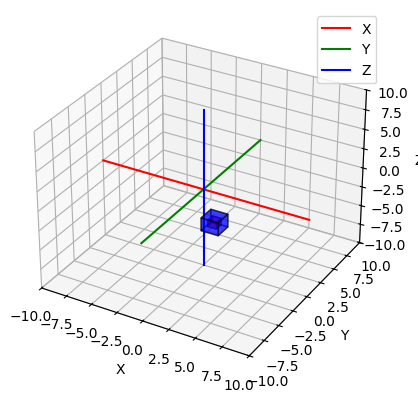

In [105]:
cube_vertices = create_random_cube()

scale_factor = 0.5
scaled_vertices = scale_cube(cube_vertices, scale_factor)

plot_cubes(cube_vertices, scaled_vertices)

### Reflecting the Cube

In [106]:
def reflect_cube(vertices):
    vertices_homogeneous = np.column_stack((vertices, np.ones(vertices.shape[0])))
    reflection_matrix = np.array([[-1, 0, 0, 0],
                                  [0, -1, 0, 0],
                                  [0, 0, -1, 0],
                                  [0, 0, 0, 1]])
    reflected_vertices_homogeneous = vertices_homogeneous @ reflection_matrix.T
    return reflected_vertices_homogeneous[:, :3]

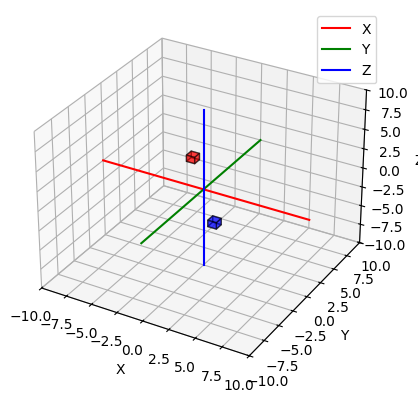

In [107]:
reflected_vertices = reflect_cube(scaled_vertices)

plot_cubes(scaled_vertices, reflected_vertices)

In [108]:
def reflect_cube_plane(vertices, plane="XY"):
    vertices_homogeneous = np.column_stack((vertices, np.ones(vertices.shape[0])))

    if plane == "XY":
        reflection_matrix = np.array([[1, 0, 0, 0],
                                      [0, 1, 0, 0],
                                      [0, 0, -1, 0],
                                      [0, 0, 0, 1]])
    elif plane == "XZ":
        reflection_matrix = np.array([[1, 0, 0, 0],
                                      [0, -1, 0, 0],
                                      [0, 0, 1, 0],
                                      [0, 0, 0, 1]])
    elif plane == "YZ":
        reflection_matrix = np.array([[-1, 0, 0, 0],
                                      [0, 1, 0, 0],
                                      [0, 0, 1, 0],
                                      [0, 0, 0, 1]])
    else:
        raise ValueError("Invalid plane. Choose from 'XY', 'XZ', or 'YZ'.")

    reflected_vertices_homogeneous = vertices_homogeneous @ reflection_matrix.T
    return reflected_vertices_homogeneous[:, :3]


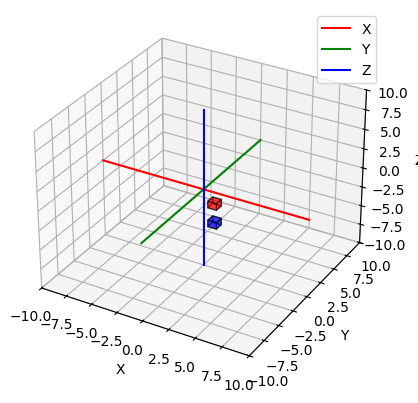

In [109]:
reflected_vertices_plane = reflect_cube_plane(scaled_vertices)

plot_cubes(scaled_vertices, reflected_vertices_plane)

### Rotated

In [110]:
def generate_random_line():
    point = np.random.uniform(-5, 5, size=3)
    direction = np.random.uniform(-1, 1, size=3)
    direction /= np.linalg.norm(direction)
    return point, direction

In [111]:
def rotated_line_cube(cube_vertices, phi, point, direction):
    point = np.array(point, dtype=float)
    direction = np.array(direction, dtype=float)
    phi = float(phi)

    vertices_h = np.hstack((cube_vertices, np.ones((cube_vertices.shape[0], 1)))).T  # (4, N)

    T = np.eye(4)
    T[:3, 3] = -point

    d_yz = np.sqrt(direction[1] ** 2 + direction[2] ** 2)
    cos_psi = direction[2] / d_yz
    sin_psi = direction[1] / d_yz

    R_x = np.array([
        [1, 0,        0,       0],
        [0, cos_psi, -sin_psi, 0],
        [0, sin_psi,  cos_psi, 0],
        [0, 0,        0,       1]
    ])

    d_xyz = np.sqrt(direction[0] ** 2 + direction[1] ** 2 + direction[2] ** 2)
    d_xz = np.sqrt(direction[0] ** 2 + (direction[1] ** 2 + direction[2] ** 2) * (direction[2] ** 2 / d_yz ** 2))

    cos_theta = d_yz / d_xyz
    sin_theta = direction[0] / d_xyz

    R_y = np.array([
        [ cos_theta, 0, sin_theta, 0],
        [ 0,         1, 0,         0],
        [-sin_theta, 0, cos_theta, 0],
        [ 0,         0, 0,         1]
    ])

    R_z = np.array([
        [np.cos(phi), -np.sin(phi), 0, 0],
        [np.sin(phi),  np.cos(phi), 0, 0],
        [0,            0,           1, 0],
        [0,            0,           0, 1]
    ])

    T_inv = np.linalg.inv(T)
    R_x_inv = np.linalg.inv(R_x)
    R_y_inv = np.linalg.inv(R_y)

    M = T_inv @ R_x_inv @ R_y_inv @ R_z @ R_y @ R_x @ T

    rotated = (M @ vertices_h).T[:, :3]

    return rotated


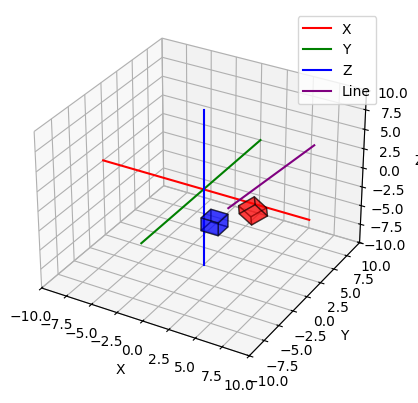

In [115]:
point, direction = generate_random_line()
rotated_cube = rotated_line_cube(cube_vertices, 45, point, direction)
plot_cubes(cube_vertices, rotated_cube, line_data=(point, direction))

### Plane

In [94]:
def generate_random_plane():
    point = np.random.uniform(-5, 5, size=3)
    normal = np.random.uniform(-1, 1, size=3)
    normal /= np.linalg.norm(normal)
    return point, normal

In [ ]:
def reflected_plane_cube(cube_vertices, phi, point, direction):
    point = np.array(point, dtype=float)
    direction = np.array(direction, dtype=float)
    phi = float(phi)

    vertices_h = np.hstack((cube_vertices, np.ones((cube_vertices.shape[0], 1)))).T  # (4, N)

    T = np.eye(4)
    T[:3, 3] = -point

    d_yz = np.sqrt(direction[1] ** 2 + direction[2] ** 2)
    cos_psi = direction[2] / d_yz
    sin_psi = direction[1] / d_yz

    R_x = np.array([
        [1, 0,        0,       0],
        [0, cos_psi, -sin_psi, 0],
        [0, sin_psi,  cos_psi, 0],
        [0, 0,        0,       1]
    ])

    d_xyz = np.sqrt(direction[0] ** 2 + direction[1] ** 2 + direction[2] ** 2)
    d_xz = np.sqrt(direction[0] ** 2 + (direction[1] ** 2 + direction[2] ** 2) * (direction[2] ** 2 / d_yz ** 2))

    cos_theta = d_yz / d_xyz
    sin_theta = direction[0] / d_xyz

    R_y = np.array([
        [ cos_theta, 0, sin_theta, 0],
        [ 0,         1, 0,         0],
        [-sin_theta, 0, cos_theta, 0],
        [ 0,         0, 0,         1]
    ])

    R_z = np.array([
        [np.cos(phi), -np.sin(phi), 0, 0],
        [np.sin(phi),  np.cos(phi), 0, 0],
        [0,            0,           1, 0],
        [0,            0,           0, 1]
    ])

    T_inv = np.linalg.inv(T)
    R_x_inv = np.linalg.inv(R_x)
    R_y_inv = np.linalg.inv(R_y)

    M = T_inv @ R_x_inv @ R_y_inv @ R_z @ R_y @ R_x @ T

    rotated = (M @ vertices_h).T[:, :3]

    return rotated


[ 0.27262787 -0.73849825 -0.61668013]


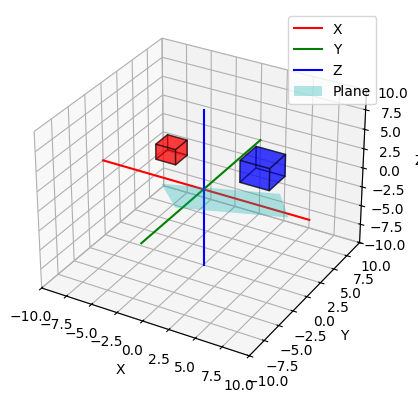

In [98]:
cube = create_random_cube()
plane_point, plane_normal = generate_random_plane()

plot_cubes(cube, scaled_vertices, plane_data=(plane_point, plane_normal))